In [1]:
import torch
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.data import InMemoryDataset, Data
from torch_geometric.datasets import ExplainerDataset
from torch_geometric.datasets.graph_generator import BAGraph
from torch_geometric.datasets.motif_generator import HouseMotif, CycleMotif
from typing import Optional, Callable, List
import os
from utils.data import dataset_description,load_data
from utils.visualization import visualize_explanation

c:\Users\mahboub\miniforge3\envs\GNN\lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\mahboub\miniforge3\envs\GNN\Lib\site-packages\torch_scatter\_version_cpu.pyd
  import torch_geometric.typing
c:\Users\mahboub\miniforge3\envs\GNN\lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\mahboub\miniforge3\envs\GNN\Lib\site-packages\torch_cluster\_version_cpu.pyd
  import torch_geometric.typing
c:\Users\mahboub\miniforge3\envs\GNN\lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: Could not load this library: C:\Users\mahboub\miniforge3\envs\GNN\Lib\site-packages\torch_spline_conv\_version_cpu.pyd
  import torch_geometric.typing
c:

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [3]:
dataset = load_data(with_gt=False)
dataset_gt=load_data(with_gt=True)


In [4]:
data = dataset[0]
print(f"num_nodes: {data.num_nodes}")
print(f"edge_index shape: {data.edge_index.shape}")
print(f"تعداد یال‌های منحصربه‌فرد (بدون خود-حلقه): {len(set((min(u,v), max(u,v)) for u,v in data.edge_index.T if u!=v))}")

num_nodes: 25
edge_index shape: torch.Size([2, 50])
تعداد یال‌های منحصربه‌فرد (بدون خود-حلقه): 50


In [5]:
data = dataset_gt[0]
print(f"num_nodes: {data.num_nodes}")
print(f"node_mask shape: {data.node_mask.shape}")
print(f"edge_mask shape: {data.edge_mask.shape}")
print(f"edge_index shape: {data.edge_index.shape}")
print(f"تعداد یال‌های منحصربه‌فرد (بدون خود-حلقه): {len(set((min(u,v), max(u,v)) for u,v in data.edge_index.T if u!=v))}")

num_nodes: 25
node_mask shape: torch.Size([25])
edge_mask shape: torch.Size([52])
edge_index shape: torch.Size([2, 52])
تعداد یال‌های منحصربه‌فرد (بدون خود-حلقه): 52


In [18]:
sample=dataset[1]

In [30]:
sample_list=[]

In [31]:
for i in range(len(dataset)):
    if len(dataset[i].edge_index[0])!=50:
        sample_list.append(i)


In [40]:
len(sample_list)

520

In [42]:
sample=dataset[sample_list[100]]
print(sample)

Data(x=[25, 10], edge_index=[2, 52], y=[1])


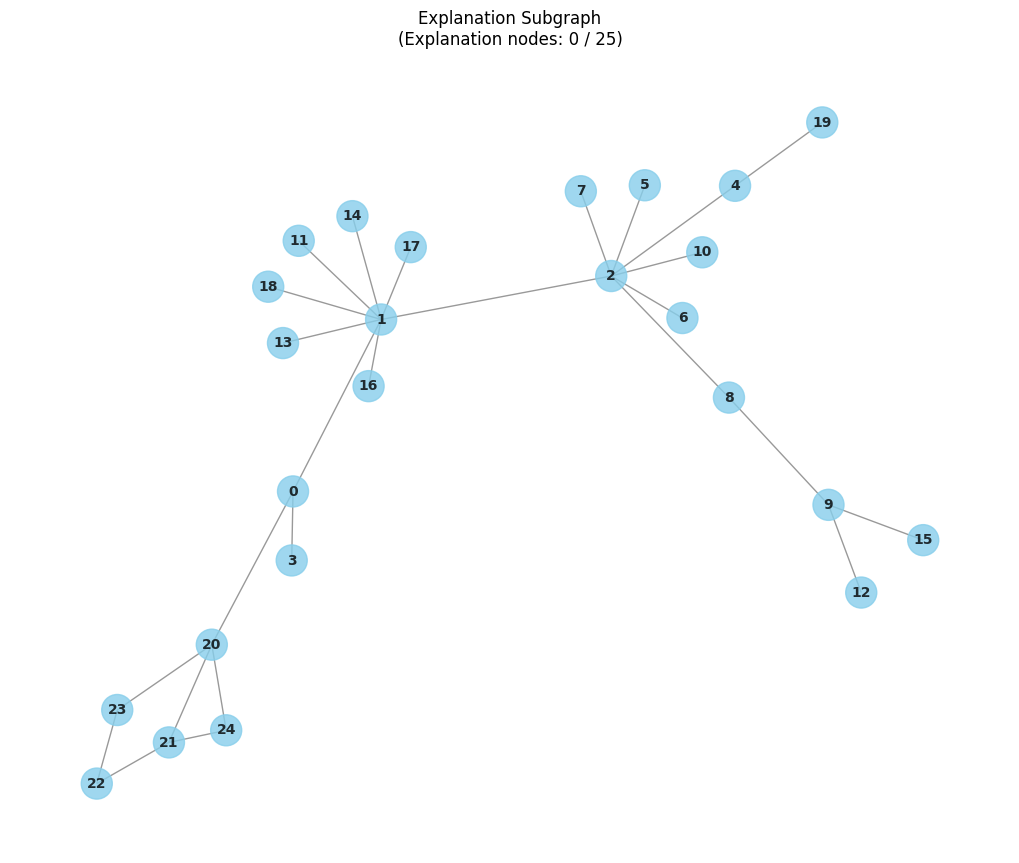

In [43]:
visualize_explanation(sample,explanation_node_indices=[])

In [44]:
sample_list=[]

In [45]:
for i in range(len(dataset_gt)):
    if len(dataset_gt[i].edge_index[0])!=50:
        sample_list.append(i)


In [46]:
len(sample_list)

723

In [52]:
sample=dataset_gt[sample_list[600]]
print(sample)

Data(x=[25, 10], edge_index=[2, 46], y=[1], node_mask=[25], edge_mask=[46], motif_nodes=[5])


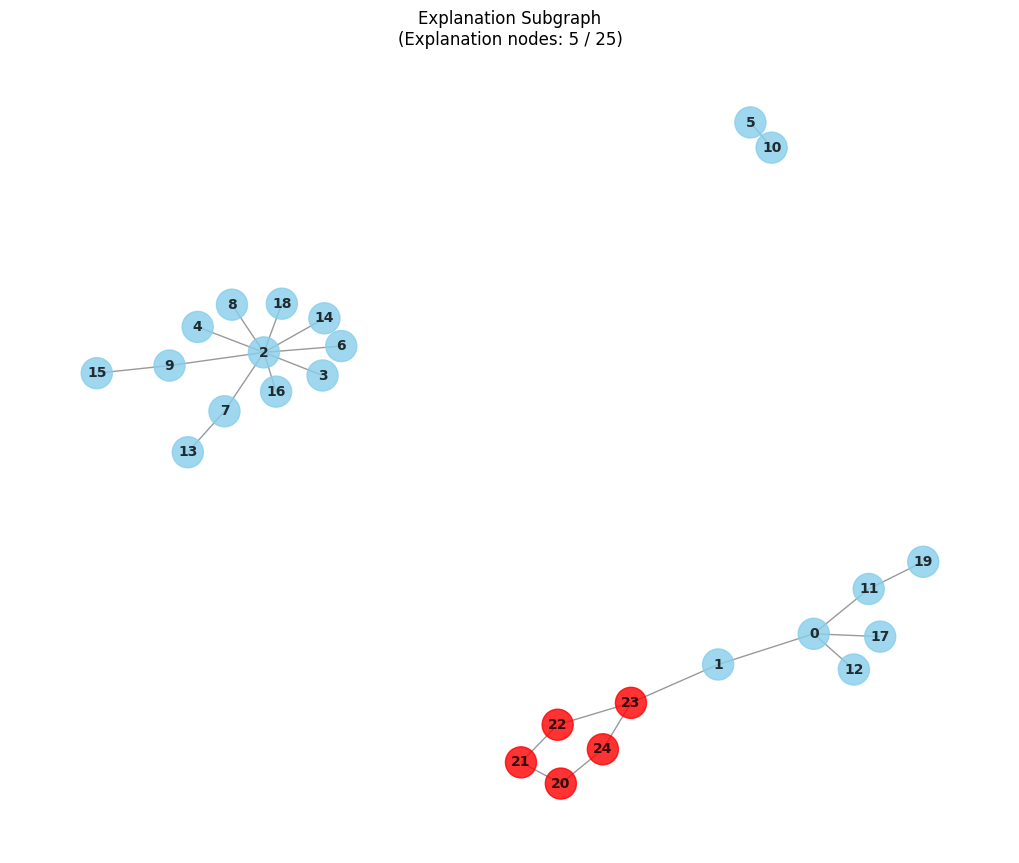

In [53]:
visualize_explanation(sample,explanation_node_indices=sample.motif_nodes)